# The Bread Basket — impulso y compra rápida

EDA y modelos sobre tickets de panadería/café: **hora del día**, tamaño de ticket e ítems de impulso.

- Datos: `data/kaggle/bread-basket/bread basket.csv`
- Uso Culebra: proxy **compra rápida 12–20 €** e **impulso en caja**
- Mapa: `docs/Variables_Decision_Datasets_Kaggle.md`


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


## Cargar dataset

In [2]:
here = Path.cwd()
candidates = [
    here / "bread basket.csv",
    here / "data" / "kaggle" / "bread-basket" / "bread basket.csv",
    Path("/kaggle/input"),
]
path = None
for c in candidates:
    if c.is_file():
        path = c
        break
    if c.is_dir():
        found = list(c.rglob("*bread*basket*.csv")) + list(c.rglob("*Bread*.csv"))
        if found:
            path = found[0]
            break
if path is None:
    raise FileNotFoundError("No se encuentra bread basket.csv")

raw = pd.read_csv(path)
raw["date_time"] = pd.to_datetime(raw["date_time"], dayfirst=True, errors="coerce")
raw["Item"] = raw["Item"].astype(str).str.strip()
raw["hour"] = raw["date_time"].dt.hour
raw["date"] = raw["date_time"].dt.date
print("Dataset path:", path.resolve())
print(raw.shape)
raw.head()


Dataset path: C:\Users\chuwi\Documents\culebra\data\kaggle\bread-basket\bread basket.csv
(20507, 7)


,Transaction,Item,date_time,period_day,weekday_weekend,hour,date
0,1,Bread,2016-10-30 09:58:00,morning,weekend,9,2016-10-30
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,10,2016-10-30
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,10,2016-10-30
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,10,2016-10-30
4,3,Jam,2016-10-30 10:07:00,morning,weekend,10,2016-10-30


## Resumen rápido

In [3]:
tx = (
    raw.groupby("Transaction")
    .agg(
        n_items=("Item", "nunique"),
        period_day=("period_day", "first"),
        weekday_weekend=("weekday_weekend", "first"),
        hour=("hour", "min"),
        date=("date", "first"),
        items=("Item", lambda s: sorted(set(s))),
    )
    .reset_index()
)
tx["has_coffee"] = tx["items"].apply(lambda xs: int("Coffee" in xs))
tx["has_bread"] = tx["items"].apply(lambda xs: int("Bread" in xs))
tx["multi_item"] = (tx["n_items"] >= 2).astype(int)

print("Tickets:", len(tx))
print("Ítems únicos:", raw["Item"].nunique())
print("Media ítems/ticket:", round(tx["n_items"].mean(), 2))
print("% multi-ítem (≥2):", round(tx["multi_item"].mean() * 100, 1), "%")
print("% con Coffee (ancla impulso):", round(tx["has_coffee"].mean() * 100, 1), "%")
display(tx[["n_items", "has_coffee", "multi_item"]].describe())


Tickets: 9465
Ítems únicos: 94
Media ítems/ticket: 2.0
% multi-ítem (≥2): 58.3 %
% con Coffee (ancla impulso): 47.8 %


,n_items,has_coffee,multi_item
count,9465.000000,9465.000000,9465.000000
mean,1.995457,0.478394,0.582884
std,1.129543,0.499559,0.493108
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,2.000000,0.000000,1.000000
75%,3.000000,1.000000,1.000000
max,10.000000,1.000000,1.000000


## Top ítems y franja horaria

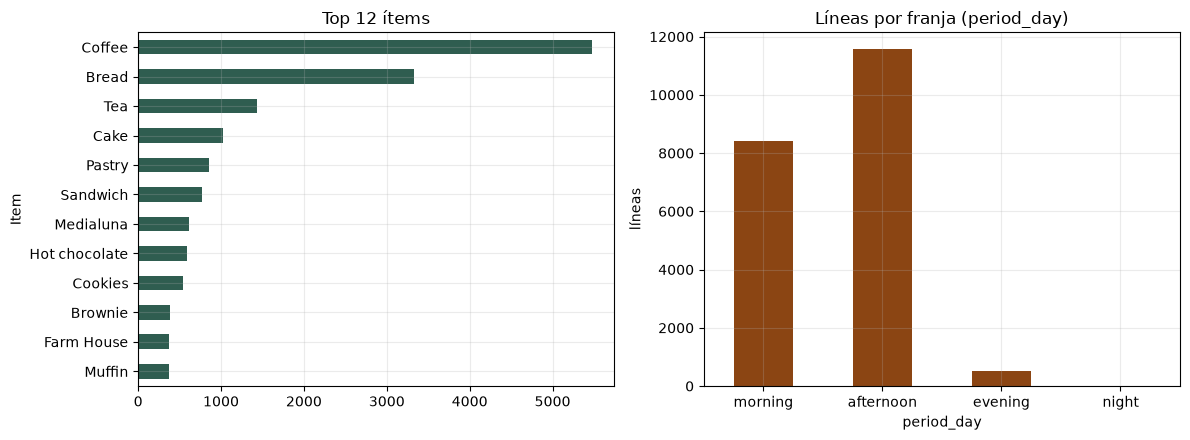

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
raw["Item"].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[0], color="#2f5d50")
axes[0].set_title("Top 12 ítems")

raw.groupby("period_day").size().reindex(
    ["morning", "afternoon", "evening", "night"]
).dropna().plot(kind="bar", ax=axes[1], color="#8b4513", rot=0)
axes[1].set_title("Líneas por franja (period_day)")
axes[1].set_ylabel("líneas")
plt.tight_layout()
plt.show()


## Impulso por hora — ¿cuándo sube el attach?

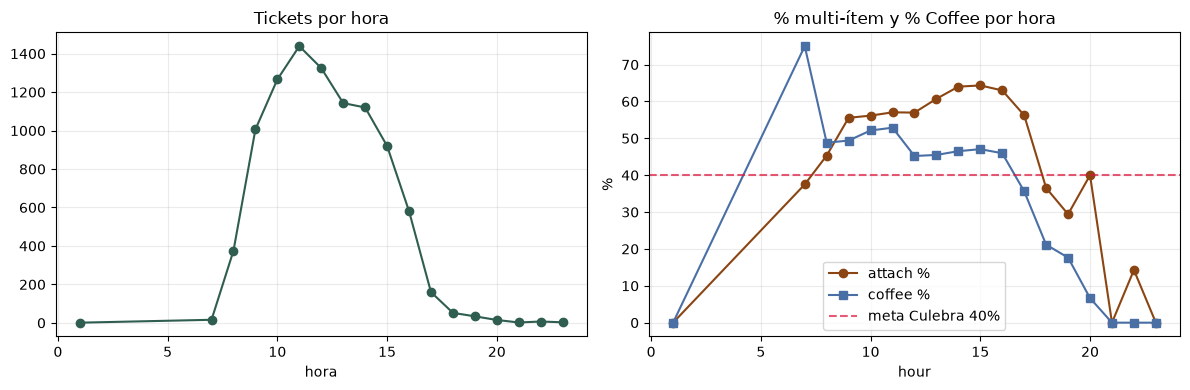

tickets  avg_items  attach_pct
period_day weekday_weekend                                
afternoon  weekday             3325      2.028       0.603
           weekend             1764      2.236       0.635
evening    weekday              169      1.988       0.521
           weekend               92      1.674       0.402
morning    weekday             2648      1.793       0.530
           weekend             1455      2.027       0.593
night      weekday                3      1.333       0.333
           weekend                9      1.000       0.000

In [5]:
by_hour = tx.groupby("hour").agg(
    tickets=("Transaction", "count"),
    avg_items=("n_items", "mean"),
    attach_pct=("multi_item", "mean"),
    coffee_pct=("has_coffee", "mean"),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_hour["tickets"].plot(ax=axes[0], marker="o", color="#2f5d50")
axes[0].set_title("Tickets por hora")
axes[0].set_xlabel("hora")

by_hour["attach_pct"].mul(100).plot(ax=axes[1], marker="o", color="#8b4513", label="attach %")
by_hour["coffee_pct"].mul(100).plot(ax=axes[1], marker="s", color="#4a6fa5", label="coffee %")
axes[1].axhline(40, color="crimson", ls="--", alpha=0.7, label="meta Culebra 40%")
axes[1].set_title("% multi-ítem y % Coffee por hora")
axes[1].set_ylabel("%")
axes[1].legend()
plt.tight_layout()
plt.show()

by_period = tx.groupby(["period_day", "weekday_weekend"]).agg(
    tickets=("Transaction", "count"),
    avg_items=("n_items", "mean"),
    attach_pct=("multi_item", "mean"),
).round(3)
display(by_period)


## Compra rápida vs cesta (proxy Culebra)

En panadería, ticket de **1 ítem** ≈ compra rápida; **≥2** ≈ impulso/attach.
En showroom: quick buy 12–20 € vs cesta+impulso.

Compra rápida (1 ítem): 3948 (41.7%)
Attach / multi:         5517 (58.3%)
Meta Culebra quick buy ≥ 20% del mix — aquí 1-ítem es el proxy.


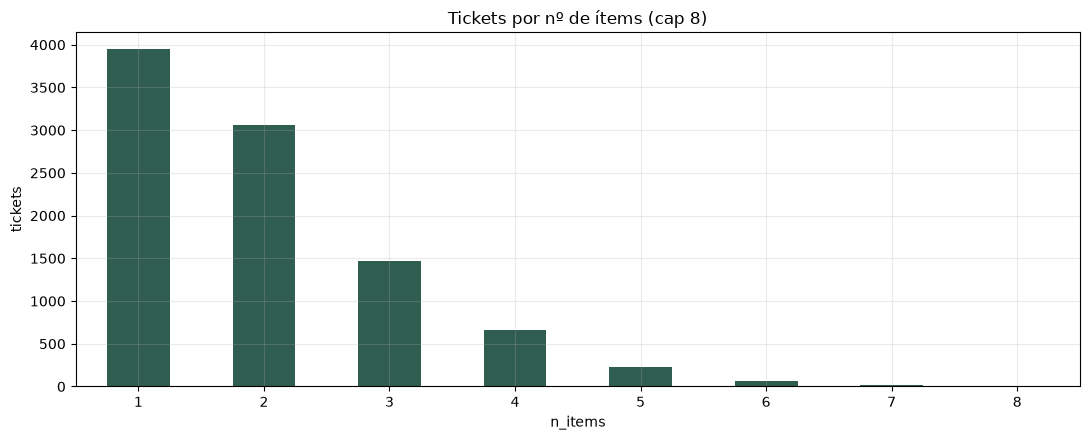

Top ítems en compra rápida (1 línea):


Item
Coffee           1386
Bread            1265
Tea               218
Farm House        203
Scandinavian      115
Cake              103
Hot chocolate      78
Sandwich           73
Pastry             70
Baguette           64
Name: count, dtype: int64

In [6]:
quick = tx[tx["n_items"] == 1]
basketish = tx[tx["n_items"] >= 2]
print(f"Compra rápida (1 ítem): {len(quick)} ({len(quick)/len(tx)*100:.1f}%)")
print(f"Attach / multi:         {len(basketish)} ({len(basketish)/len(tx)*100:.1f}%)")
print("Meta Culebra quick buy ≥ 20% del mix — aquí 1-ítem es el proxy.")

fig, ax = plt.subplots()
tx["n_items"].clip(upper=8).value_counts().sort_index().plot(kind="bar", ax=ax, color="#2f5d50", rot=0)
ax.set_title("Tickets por nº de ítems (cap 8)")
ax.set_xlabel("n_items")
ax.set_ylabel("tickets")
plt.tight_layout()
plt.show()

# Ítems más frecuentes en tickets de 1 sola línea (compra rápida)
quick_items = raw[raw["Transaction"].isin(quick["Transaction"])]["Item"].value_counts().head(10)
print("Top ítems en compra rápida (1 línea):")
display(quick_items)


## Modelo: predecir nº de ítems (regresión)

In [7]:
feat = tx[["period_day", "weekday_weekend", "hour", "has_coffee", "has_bread"]].copy()
y = tx["n_items"]

pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["period_day", "weekday_weekend"]),
        ("num", "passthrough", ["hour", "has_coffee", "has_bread"]),
    ]
)
reg = Pipeline(
    [
        ("pre", pre),
        ("rf", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ]
)
X_train, X_test, y_train, y_test = train_test_split(feat, y, test_size=0.25, random_state=42)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
print("MAE n_items:", round(mean_absolute_error(y_test, pred), 3))
print("R²:", round(r2_score(y_test, pred), 3))


MAE n_items: 0.812
R²: 0.169


## Modelo: ¿habrá impulso? (multi-ítem sí/no)

Accuracy multi-ítem: 0.645
              precision    recall  f1-score   support

           0      0.573     0.584     0.578       987
           1      0.698     0.689     0.694      1380

    accuracy                          0.645      2367
   macro avg      0.636     0.636     0.636      2367
weighted avg      0.646     0.645     0.646      2367



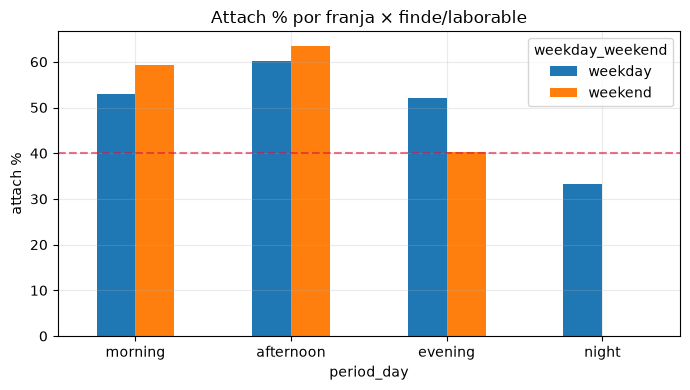

In [8]:
y_cls = tx["multi_item"]
clf = Pipeline(
    [
        ("pre", pre),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ]
)
X_train, X_test, y_train, y_test = train_test_split(
    feat, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print("Accuracy multi-ítem:", round(accuracy_score(y_test, pred), 3))
print(classification_report(y_test, pred, digits=3))

# Attach medio por franja (decidir staffing / degustación)
pivot = tx.pivot_table(
    index="period_day", columns="weekday_weekend", values="multi_item", aggfunc="mean"
).reindex(["morning", "afternoon", "evening", "night"])
fig, ax = plt.subplots(figsize=(7, 4))
pivot.mul(100).plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("attach %")
ax.set_title("Attach % por franja × finde/laborable")
ax.axhline(40, color="crimson", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()


## Conclusiones para decidir (Culebra)

1. **Franja horaria** importa para impulso: planificar degustación / tote / mini-cata en picos de attach.
2. **Anclas** (aquí Coffee/Bread) tiran de multi-ítem → en showroom: cesta visible + 1–2 SKU de impulso al lado.
3. Separar KPI **quick buy** (1 línea / 12–20 €) vs **attach** (≥2 / +4–12 €).
4. Sin precios €: combinar con `culebra_showroom_daily.csv` o contador quincenal del panel.
